# Jednoetapowa detekcja obiektów YOLO — analiza dokładności i czasu inferencji

**Analiza Danych Obrazowych i Multimedialnych · TEMAT 13**

Praca analizuje kompromis między **dokładnością** (mAP) a **czasem inferencji** dla jednoetapowego
detektora YOLO. Modele wytrenowane na zbiorze **COCO** są ewaluowane w trybie **zero-shot**
(bez dotrenowania) na zbiorze **Pascal VOC** (`test2007`, 4952 obrazy) — jest to test transferu
COCO → VOC, możliwy dzięki temu, że 20 klas VOC stanowi podzbiór 80 klas COCO.

Dla każdej konfiguracji raportujemy **mAP@50** i **mAP@50-95**, złożoność modelu (parametry, GFLOPs)
oraz czas przetwarzania całego zbioru testowego, przeliczony na ms/obraz.

| Eksperyment | Badana zmienna | Konfiguracje |
|:--:|---|---|
| **A** | generacja architektury | yolov8n · yolo11n · yolo26n |
| **B** | rozmiar modelu | yolo11n · yolo11s · yolo11m |
| **C** | rozdzielczość wejścia (HP1) | imgsz ∈ {320, 640, 960} |
| **D** | próg IoU w NMS (HP2) | iou ∈ {0.45, 0.6, 0.7} |

Punkt odniesienia: **yolo11n, imgsz 640, iou 0.6**.

### Dane i konfiguracja
Wyniki pochodzą z `results/results.csv` (generowane przez `experiments/run_all.sh`).

In [82]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

# spójny, minimalistyczny styl wykresów
mpl.rcParams.update({
    "figure.figsize": (7, 4), "figure.dpi": 110, "savefig.dpi": 120,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlepad": 12, "axes.labelcolor": "#333", "axes.edgecolor": "#cccccc",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#ececec", "grid.linewidth": 0.9,
    "xtick.color": "#555", "ytick.color": "#555",
})
INK, ACCENT, GRAY = "#1f2a44", "#e0654f", "#aab2c0"
TRIO = ["#cdd5e2", "#7c89a6", "#1f2a44"]

# wczytanie wyników (niezależnie od katalogu uruchomienia)
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "config.yaml").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "results"
df = pd.read_csv(RESULTS / "results.csv"); df["model"] = df["model"].astype(str)
voc = df[df.dataset == "VOC_cocomap.yaml"].copy()

def tabela(d, fmt=None, hi=None):
    s = d.style.hide(axis="index")
    s = s.format(fmt) if fmt else s.format(precision=3)
    s = s.set_table_styles([
        {"selector": "th", "props": "background:#1f2a44;color:#fff;font-weight:600;padding:6px 12px;text-align:center;"},
        {"selector": "td", "props": "padding:5px 12px;text-align:center;color:#222;"},
        {"selector": "tr:nth-child(even) td", "props": "background:#f6f7f9;"},
    ])
    if hi:
        s = s.highlight_max(subset=hi, props="background:#fde8e3;font-weight:700;color:#b03a26;")
    return s

def slupki_etykiety(ax, fmt="{:.3f}", off=2):
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", xytext=(0, off),
                    textcoords="offset points", fontsize=8.5, color="#333")

print(f"Wczytano wyniki: {len(df)} konfiguracji (w tym {len(voc)} na VOC).")

Wczytano wyniki: 18 konfiguracji (w tym 11 na VOC).


## 1 · Przykładowa detekcja
Pojedynczy przebieg sieci YOLO11n zwraca jednocześnie lokalizacje (ramki) i klasy obiektów.

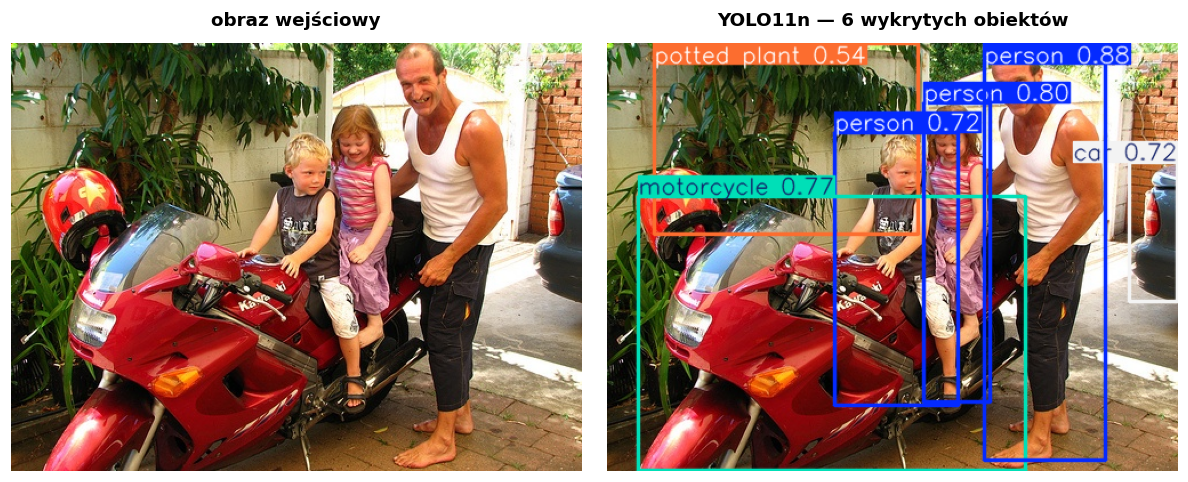

Wykryte obiekty:  person ×3    motorcycle ×1    car ×1    potted plant ×1


In [83]:
import yaml
from ultralytics import YOLO

d = yaml.safe_load((ROOT / "VOC_cocomap.yaml").read_text())
cand = Path(d["path"]) / d["val"] / "000058.jpg"
img = str(cand) if cand.exists() else "https://ultralytics.com/images/bus.jpg"

model = YOLO("yolo11n.pt")
res = model.predict(img, conf=0.35, device="cpu", verbose=False)[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].imshow(res.orig_img[..., ::-1]); ax[0].set_title("obraz wejściowy")
ax[1].imshow(res.plot()[..., ::-1])
ax[1].set_title(f"YOLO11n — {len(res.boxes)} wykrytych obiektów")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

vc = pd.Series([model.names[int(c)] for c in res.boxes.cls]).value_counts()
print("Wykryte obiekty:  " + "    ".join(f"{k} ×{v}" for k, v in vc.items()))

## 2 · Charakterystyka modeli
Złożoność (liczba parametrów, GFLOPs) oraz jakość i czas inferencji dla konfiguracji
bazowej (imgsz 640, iou 0.6).

In [84]:
base = (voc[(voc.imgsz == 640) & (voc.iou == 0.6)]
        .sort_values("params_M")
        [["model", "params_M", "GFLOPs", "mAP50", "mAP50_95", "ms_per_image"]]
        .rename(columns={"params_M": "params [M]", "mAP50": "mAP@50",
                         "mAP50_95": "mAP@50-95", "ms_per_image": "ms/obraz"}))
display(tabela(base, fmt={"params [M]": "{:.2f}", "GFLOPs": "{:.2f}", "mAP@50": "{:.3f}",
                          "mAP@50-95": "{:.3f}", "ms/obraz": "{:.1f}"},
               hi=["mAP@50", "mAP@50-95"]))

model,params [M],GFLOPs,mAP@50,mAP@50-95,ms/obraz
yolo26n,2.57,6.12,0.817,0.631,58.5
yolo11n,2.62,6.61,0.823,0.622,54.7
yolov8n,3.16,8.86,0.808,0.598,57.5
yolo11s,9.46,21.72,0.861,0.677,145.3
yolo26s,10.01,22.84,0.859,0.686,150.4
yolov8s,11.17,28.82,0.847,0.657,147.4
yolo11m,20.11,68.53,0.871,0.704,394.2


## 3 · Eksperyment A — generacja architektury
Trzy generacje w rozmiarze „n": yolov8n (2023), yolo11n (2024), yolo26n (2025).
Model yolo26 jest end-to-end (bez NMS), dlatego sweep progu IoU (Eksp. D) wykonano tylko dla yolo11n.

model,params [M],GFLOPs,mAP@50,mAP@50-95,ms/obraz
yolov8n,3.16,8.86,0.8077,0.5979,57.5
yolo11n,2.62,6.61,0.8227,0.6219,54.7
yolo26n,2.57,6.12,0.8172,0.6309,58.5


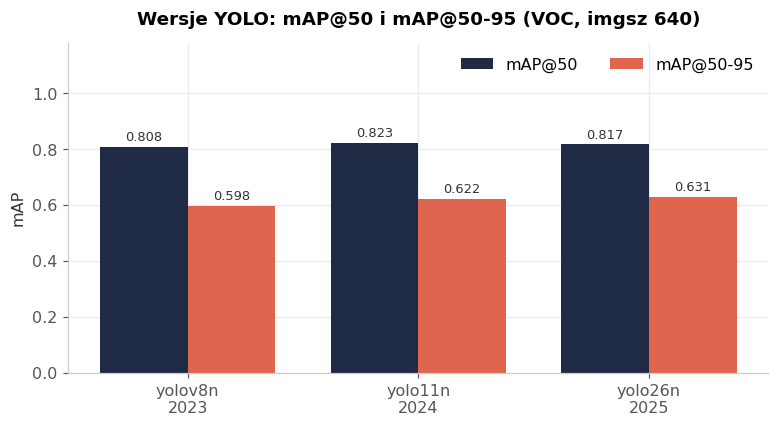

mAP@50    — najwyższe: yolo11n (0.8227)
mAP@50-95 — najwyższe: yolo26n (0.6309)


In [85]:
ver = ["yolov8n", "yolo11n", "yolo26n"]
A = voc[(voc.model.isin(ver)) & (voc.imgsz == 640) & (voc.iou == 0.6)].set_index("model").reindex(ver)

tab = A.reset_index()[["model", "params_M", "GFLOPs", "mAP50", "mAP50_95", "ms_per_image"]].rename(
    columns={"params_M": "params [M]", "mAP50": "mAP@50", "mAP50_95": "mAP@50-95", "ms_per_image": "ms/obraz"})
display(tabela(tab, fmt={"params [M]": "{:.2f}", "GFLOPs": "{:.2f}", "mAP@50": "{:.4f}",
                         "mAP@50-95": "{:.4f}", "ms/obraz": "{:.1f}"}, hi=["mAP@50", "mAP@50-95"]))

x = np.arange(len(ver)); w = 0.38
fig, ax = plt.subplots(figsize=(7.2, 4))
ax.bar(x - w/2, A["mAP50"], w, color=INK, label="mAP@50")
ax.bar(x + w/2, A["mAP50_95"], w, color=ACCENT, label="mAP@50-95")
slupki_etykiety(ax, "{:.3f}")
ax.set_xticks(x); ax.set_xticklabels([f"{m}\n{y}" for m, y in zip(ver, [2023, 2024, 2025])])
ax.set_ylim(0, 1.18); ax.set_ylabel("mAP")
ax.legend(frameon=False, loc="upper right", ncol=2)
ax.set_title("Wersje YOLO: mAP@50 i mAP@50-95 (VOC, imgsz 640)")
plt.tight_layout(); plt.show()

print(f"mAP@50    — najwyższe: {A['mAP50'].idxmax()} ({A['mAP50'].max():.4f})")
print(f"mAP@50-95 — najwyższe: {A['mAP50_95'].idxmax()} ({A['mAP50_95'].max():.4f})")

## 4 · Eksperyment A′ — wersje na rozmiarze s
Na rozmiarze „n" różnice między generacjami były niewielkie. Aby sprawdzić, czy wzorzec utrzymuje się
przy większym modelu, powtarzamy porównanie wersji na rozmiarze „s" (yolov8s, yolo11s, yolo26s).
Tabela replikacji zestawia yolo11 vs yolo26 w czterech warunkach (rozmiar n/s × zbiór VOC/COCO-20).

model,params [M],GFLOPs,mAP@50,mAP@50-95,ms/obraz
yolov8s,11.17,28.82,0.8471,0.6569,147.4
yolo11s,9.46,21.72,0.8614,0.6772,145.3
yolo26s,10.01,22.84,0.8589,0.6860,150.4


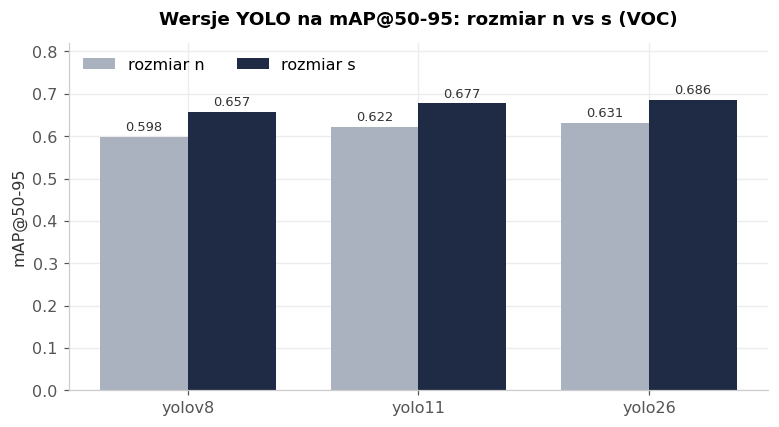

warunek,mAP@50 (11 / 26),Δ@50 [pp],mAP@50-95 (11 / 26),Δ@50-95 [pp]
n · VOC,0.823 / 0.817,-0.55,0.622 / 0.631,+0.90
n · COCO-20,0.648 / 0.643,-0.45,0.458 / 0.463,+0.59
s · VOC,0.861 / 0.859,-0.25,0.677 / 0.686,+0.88
s · COCO-20,0.719 / 0.720,+0.09,0.527 / 0.536,+0.92


Δ = yolo26 − yolo11.  Na mAP@50-95 Δ > 0 we wszystkich 4 warunkach; na mAP@50 Δ ≈ 0 lub lekko ujemne.


In [86]:
ver_s = ["yolov8s", "yolo11s", "yolo26s"]
As = voc[(voc.model.isin(ver_s)) & (voc.imgsz == 640) & (voc.iou == 0.6)].set_index("model").reindex(ver_s)
tabA = As.reset_index()[["model", "params_M", "GFLOPs", "mAP50", "mAP50_95", "ms_per_image"]].rename(
    columns={"params_M": "params [M]", "mAP50": "mAP@50", "mAP50_95": "mAP@50-95", "ms_per_image": "ms/obraz"})
display(tabela(tabA, fmt={"params [M]": "{:.2f}", "GFLOPs": "{:.2f}", "mAP@50": "{:.4f}",
                          "mAP@50-95": "{:.4f}", "ms/obraz": "{:.1f}"}, hi=["mAP@50", "mAP@50-95"]))

# mAP@50-95 wg generacji, rozmiar n vs s (VOC)
gen = ["yolov8", "yolo11", "yolo26"]
def val(model, metric):
    r = voc[(voc.model == model) & (voc.imgsz == 640) & (voc.iou == 0.6)]
    return float(r[metric].iloc[0])
n_vals = [val(g + "n", "mAP50_95") for g in gen]
s_vals = [val(g + "s", "mAP50_95") for g in gen]

x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(7.2, 4))
ax.bar(x - w/2, n_vals, w, color=GRAY, label="rozmiar n")
ax.bar(x + w/2, s_vals, w, color=INK, label="rozmiar s")
slupki_etykiety(ax, "{:.3f}")
ax.set_xticks(x); ax.set_xticklabels(gen); ax.set_ylim(0, 0.82)
ax.set_ylabel("mAP@50-95"); ax.legend(frameon=False, loc="upper left", ncol=2)
ax.set_title("Wersje YOLO na mAP@50-95: rozmiar n vs s (VOC)")
plt.tight_layout(); plt.show()

# replikacja: yolo11 vs yolo26 w 4 warunkach
def pair(model, ds):
    r = df[(df.model == model) & (df.dataset == ds) & (df.imgsz == 640) & (df.iou == 0.6)]
    return float(r["mAP50"].iloc[0]), float(r["mAP50_95"].iloc[0])
rows = []
for size in ["n", "s"]:
    for ds, lab in [("VOC_cocomap.yaml", "VOC"), ("coco20.yaml", "COCO-20")]:
        a50, a95 = pair("yolo11" + size, ds)
        b50, b95 = pair("yolo26" + size, ds)
        rows.append({"warunek": f"{size} · {lab}",
                     "mAP@50 (11 / 26)": f"{a50:.3f} / {b50:.3f}", "Δ@50 [pp]": (b50 - a50) * 100,
                     "mAP@50-95 (11 / 26)": f"{a95:.3f} / {b95:.3f}", "Δ@50-95 [pp]": (b95 - a95) * 100})
rep = pd.DataFrame(rows)
display(tabela(rep, fmt={"Δ@50 [pp]": "{:+.2f}", "Δ@50-95 [pp]": "{:+.2f}"}))
print("Δ = yolo26 − yolo11.  Na mAP@50-95 Δ > 0 we wszystkich 4 warunkach; na mAP@50 Δ ≈ 0 lub lekko ujemne.")

## 5 · Eksperyment B — rozmiar modelu
Ta sama architektura (wersja 11) w trzech rozmiarach: n, s, m.

model,params [M],GFLOPs,mAP@50,mAP@50-95,ms/obraz
yolo11n,2.62,6.61,0.823,0.622,54.7
yolo11s,9.46,21.72,0.861,0.677,145.3
yolo11m,20.11,68.53,0.871,0.704,394.2


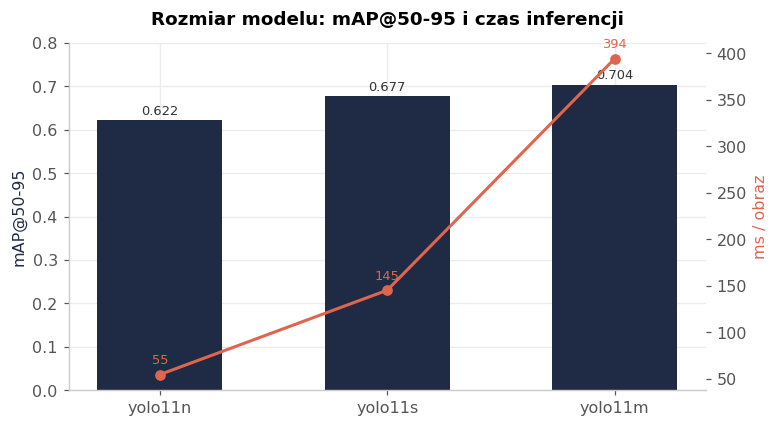

mAP@50-95 (n→s→m):  0.622 → 0.677 → 0.704      czas/obraz (n→m):  ×7.2


In [87]:
sz = ["yolo11n", "yolo11s", "yolo11m"]
B = voc[(voc.model.isin(sz)) & (voc.imgsz == 640) & (voc.iou == 0.6)].set_index("model").reindex(sz)

tab = B.reset_index()[["model", "params_M", "GFLOPs", "mAP50", "mAP50_95", "ms_per_image"]].rename(
    columns={"params_M": "params [M]", "mAP50": "mAP@50", "mAP50_95": "mAP@50-95", "ms_per_image": "ms/obraz"})
display(tabela(tab, fmt={"params [M]": "{:.2f}", "GFLOPs": "{:.2f}", "mAP@50": "{:.3f}",
                         "mAP@50-95": "{:.3f}", "ms/obraz": "{:.1f}"}, hi=["mAP@50", "mAP@50-95"]))

fig, ax1 = plt.subplots(figsize=(7.2, 4))
ax1.bar(sz, B["mAP50_95"], color=INK, width=0.55)
slupki_etykiety(ax1, "{:.3f}")
ax1.set_ylim(0, 0.8); ax1.set_ylabel("mAP@50-95", color=INK)
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(sz, B["ms_per_image"], "o-", color=ACCENT, lw=2)
ax2.set_ylabel("ms / obraz", color=ACCENT)
for s, v in zip(sz, B["ms_per_image"]):
    ax2.annotate(f"{v:.0f}", (s, v), xytext=(0, 7), textcoords="offset points",
                 ha="center", fontsize=8.5, color=ACCENT)
ax1.set_title("Rozmiar modelu: mAP@50-95 i czas inferencji")
plt.tight_layout(); plt.show()

print("mAP@50-95 (n→s→m):  " + " → ".join(f"{v:.3f}" for v in B["mAP50_95"]) +
      f"      czas/obraz (n→m):  ×{B['ms_per_image'].iloc[-1] / B['ms_per_image'].iloc[0]:.1f}")

## 6 · Eksperyment C — rozdzielczość wejścia (HP1)
Wpływ rozdzielczości obrazu wejściowego `imgsz` na jakość i czas (yolo11n, iou 0.6).

imgsz,GFLOPs,mAP@50,mAP@50-95,ms/obraz
320,1.65,0.770,0.566,21.2
640,6.61,0.823,0.622,54.7
960,14.88,0.769,0.505,148.0


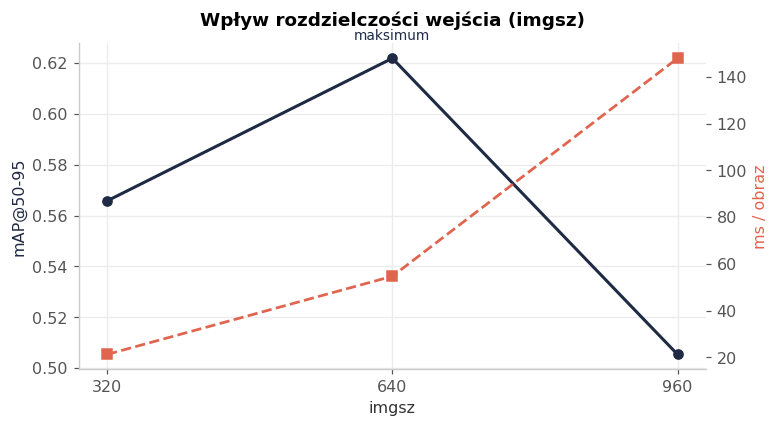

Najwyższe mAP@50-95 przy imgsz 640; przy 960 jakość spada mimo wyższego kosztu obliczeń.


In [88]:
C = voc[(voc.model == "yolo11n") & (voc.iou == 0.6)].sort_values("imgsz")
tab = C[["imgsz", "GFLOPs", "mAP50", "mAP50_95", "ms_per_image"]].rename(
    columns={"mAP50": "mAP@50", "mAP50_95": "mAP@50-95", "ms_per_image": "ms/obraz"})
display(tabela(tab, fmt={"imgsz": "{:.0f}", "GFLOPs": "{:.2f}", "mAP@50": "{:.3f}",
                         "mAP@50-95": "{:.3f}", "ms/obraz": "{:.1f}"}, hi=["mAP@50", "mAP@50-95"]))

fig, ax1 = plt.subplots(figsize=(7.2, 4))
ax1.plot(C.imgsz, C.mAP50_95, "o-", color=INK, lw=2)
ax1.set_xlabel("imgsz"); ax1.set_ylabel("mAP@50-95", color=INK); ax1.set_xticks(C.imgsz)
peak = C.loc[C.mAP50_95.idxmax()]
ax1.annotate("maksimum", (peak.imgsz, peak.mAP50_95), xytext=(0, 12),
             textcoords="offset points", ha="center", color=INK, fontsize=9)
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(C.imgsz, C.ms_per_image, "s--", color=ACCENT, lw=1.8)
ax2.set_ylabel("ms / obraz", color=ACCENT)
ax1.set_title("Wpływ rozdzielczości wejścia (imgsz)")
plt.tight_layout(); plt.show()

print("Najwyższe mAP@50-95 przy imgsz 640; przy 960 jakość spada mimo wyższego kosztu obliczeń.")

## 7 · Eksperyment D — próg IoU w NMS (HP2)
Wpływ progu IoU w Non-Maximum Suppression na mAP, precision i recall (yolo11n, imgsz 640).

iou,mAP@50,mAP@50-95,precision,recall
0.45,0.8205,0.6153,0.793,0.761
0.60,0.8227,0.6219,0.790,0.762
0.70,0.8198,0.6244,0.788,0.760


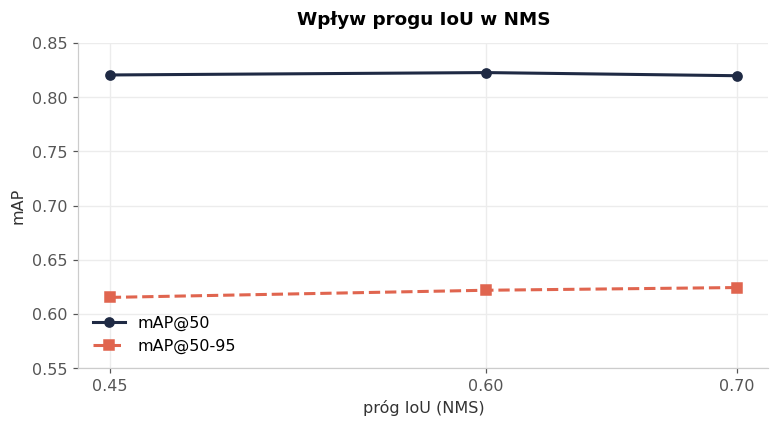

Zakres zmienności: mAP@50 0.29 pp, mAP@50-95 0.91 pp.


In [76]:
D = voc[(voc.model == "yolo11n") & (voc.imgsz == 640)].sort_values("iou")
tab = D[["iou", "mAP50", "mAP50_95", "precision", "recall"]].rename(
    columns={"mAP50": "mAP@50", "mAP50_95": "mAP@50-95"})
display(tabela(tab, fmt={"iou": "{:.2f}", "mAP@50": "{:.4f}", "mAP@50-95": "{:.4f}",
                         "precision": "{:.3f}", "recall": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(D.iou, D.mAP50, "o-", color=INK, lw=2, label="mAP@50")
ax.plot(D.iou, D.mAP50_95, "s--", color=ACCENT, lw=2, label="mAP@50-95")
ax.set_xlabel("próg IoU (NMS)"); ax.set_ylabel("mAP"); ax.set_xticks(D.iou)
ax.set_ylim(0.55, 0.85)
ax.legend(frameon=False)
ax.set_title("Wpływ progu IoU w NMS")
plt.tight_layout(); plt.show()

print(f"Zakres zmienności: mAP@50 {(D.mAP50.max() - D.mAP50.min())*100:.2f} pp, "
      f"mAP@50-95 {(D.mAP50_95.max() - D.mAP50_95.min())*100:.2f} pp.")

## 8 · Kompromis dokładność–czas
Zestawienie wszystkich konfiguracji na VOC. Linią zaznaczono front Pareto — najwyższe mAP przy danym czasie.

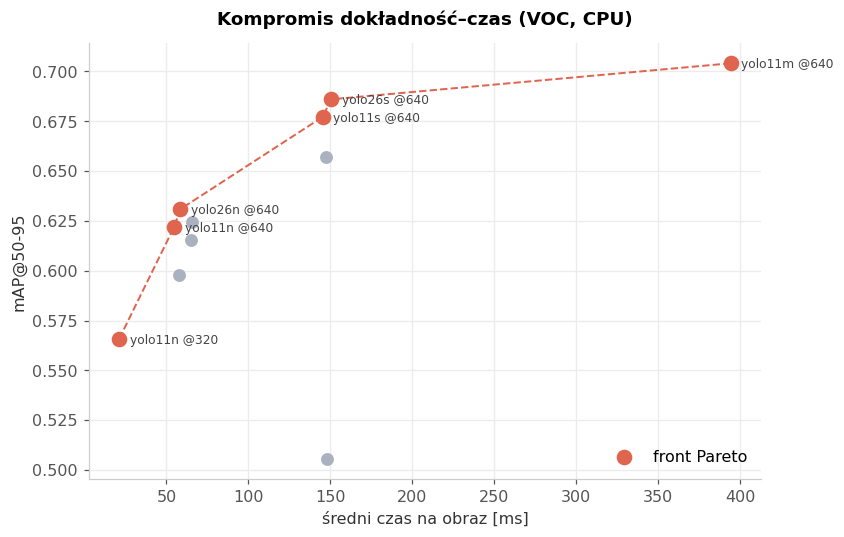

In [77]:
p = voc.sort_values("ms_per_image"); front = []; best = -1
for idx, r in p.iterrows():
    if r.mAP50_95 > best:
        front.append(idx); best = r.mAP50_95
isf = voc.index.isin(front)

fig, ax = plt.subplots(figsize=(7.8, 5))
ax.scatter(voc.loc[~isf, "ms_per_image"], voc.loc[~isf, "mAP50_95"], s=55, color=GRAY, zorder=3)
ax.scatter(voc.loc[isf, "ms_per_image"], voc.loc[isf, "mAP50_95"], s=85, color=ACCENT, zorder=4, label="front Pareto")
fr = voc.loc[isf].sort_values("ms_per_image")
ax.plot(fr.ms_per_image, fr.mAP50_95, "--", color=ACCENT, lw=1.3, zorder=2)
for _, r in fr.iterrows():
    ax.annotate(f"{r.model} @{int(r.imgsz)}", (r.ms_per_image, r.mAP50_95),
                xytext=(7, -3), textcoords="offset points", fontsize=8, color="#444")
ax.set_xlabel("średni czas na obraz [ms]")
ax.set_ylabel("mAP@50-95")
ax.legend(frameon=False, loc="lower right")
ax.set_title("Kompromis dokładność–czas (VOC, CPU)")
plt.tight_layout(); plt.show()

## 9 · Wpływ trudności zbioru na korzyści z modelu
Porównanie trzech poziomów trudności przy identycznych klasach i identycznym kodzie ewaluacji:
**VOC-20** (zero-shot na VOC), **COCO-20** (COCO val2017 ograniczone do tych samych 20 klas) oraz
oficjalne wyniki **COCO-80** (docs.ultralytics.com). VOC-20 i COCO-20 różnią się wyłącznie trudnością zdjęć.

model,VOC-20,COCO-20,COCO-80
yolov8n,59.8,43.3,37.3
yolo11n,62.2,45.8,39.5
yolo26n,63.1,46.3,40.9
yolo11s,67.7,52.7,47.0
yolo11m,70.4,57.0,51.5


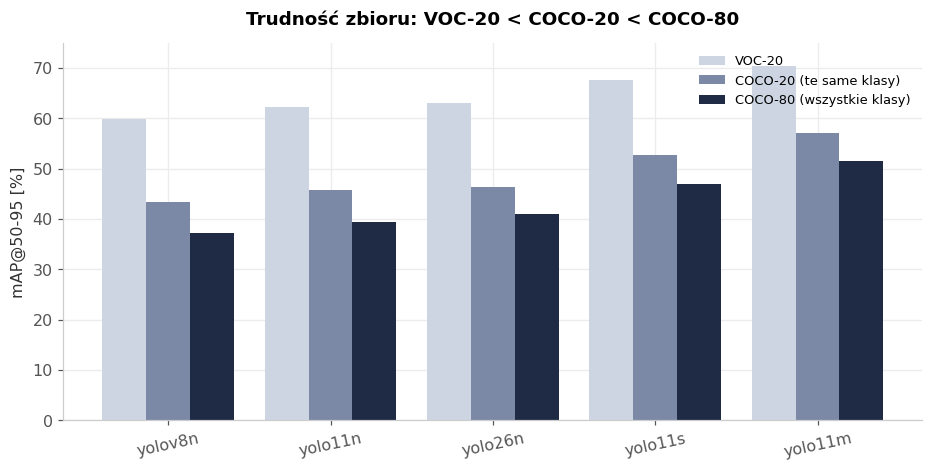

Względny przyrost mAP@50-95:
  rozmiar  11n→11m :  VOC +13%    COCO-20 +25%    COCO-80 +30%
  wersja   v8n→26n :  VOC +6%    COCO-20 +7%    COCO-80 +10%
Korzyść z większego i nowszego modelu rośnie wraz z trudnością zbioru.


In [89]:
V20 = df[(df.dataset == "VOC_cocomap.yaml") & (df.imgsz == 640) & (df.iou == 0.6)].set_index("model")
C20 = df[(df.dataset == "coco20.yaml") & (df.imgsz == 640) & (df.iou == 0.6)].set_index("model")
coco80 = {"yolov8n": 37.3, "yolo11n": 39.5, "yolo26n": 40.9, "yolo11s": 47.0, "yolo11m": 51.5}
order = ["yolov8n", "yolo11n", "yolo26n", "yolo11s", "yolo11m"]

T = pd.DataFrame({
    "model": order,
    "VOC-20": [V20.loc[m, "mAP50_95"] * 100 for m in order],
    "COCO-20": [C20.loc[m, "mAP50_95"] * 100 for m in order],
    "COCO-80": [coco80[m] for m in order],
})
display(tabela(T, fmt={"VOC-20": "{:.1f}", "COCO-20": "{:.1f}", "COCO-80": "{:.1f}"}))

x = np.arange(len(order)); w = 0.27
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(x - w, T["VOC-20"], w, color=TRIO[0], label="VOC-20")
ax.bar(x,     T["COCO-20"], w, color=TRIO[1], label="COCO-20 (te same klasy)")
ax.bar(x + w, T["COCO-80"], w, color=TRIO[2], label="COCO-80 (wszystkie klasy)")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=12)
ax.set_ylabel("mAP@50-95 [%]"); ax.set_ylim(0, 75)
ax.legend(frameon=False, fontsize=8.5)
ax.set_title("Trudność zbioru: VOC-20 < COCO-20 < COCO-80")
plt.tight_layout(); plt.savefig(RESULTS / "plot_difficulty.png"); plt.show()

def gain(a, b, d): return (d.loc[b, "mAP50_95"] / d.loc[a, "mAP50_95"] - 1) * 100
print("Względny przyrost mAP@50-95:")
print(f"  rozmiar  11n→11m :  VOC {gain('yolo11n','yolo11m',V20):+.0f}%    "
      f"COCO-20 {gain('yolo11n','yolo11m',C20):+.0f}%    COCO-80 {(coco80['yolo11m']/coco80['yolo11n']-1)*100:+.0f}%")
print(f"  wersja   v8n→26n :  VOC {gain('yolov8n','yolo26n',V20):+.0f}%    "
      f"COCO-20 {gain('yolov8n','yolo26n',C20):+.0f}%    COCO-80 {(coco80['yolo26n']/coco80['yolov8n']-1)*100:+.0f}%")
print("Korzyść z większego i nowszego modelu rośnie wraz z trudnością zbioru.")

## 10 · Pomiar opóźnień: n / s / m
Czas inferencji jednego obrazu dla trzech rozmiarów modelu (yolo11).

In [81]:
import time
print(f"{'model':>11} | {'czas [ms]':>9} | {'obiektów':>8}")
print("-" * 36)
for name in ["yolo11n.pt", "yolo11s.pt", "yolo11m.pt"]:
    mm = YOLO(name)
    mm.predict(img, device="cpu", verbose=False)               # rozgrzewka
    t0 = time.perf_counter()
    rr = mm.predict(img, device="cpu", verbose=False)
    dt = (time.perf_counter() - t0) * 1000
    print(f"{name:>11} | {dt:>9.1f} | {len(rr[0].boxes):>8}")
print("\nCzas inferencji rośnie wraz z rozmiarem modelu.")

      model | czas [ms] | obiektów
------------------------------------
 yolo11n.pt |      61.1 |        6
 yolo11s.pt |     137.1 |        5
 yolo11m.pt |     336.2 |        8

Czas inferencji rośnie wraz z rozmiarem modelu.


## Podsumowanie

- **Generacja (A, A′):** wzorzec **replikuje się w 4 warunkach** (rozmiar n i s × zbiór VOC i COCO-20):
  na **mAP@50-95 najnowszy yolo26 jest najlepszy zawsze** (Δ względem yolo11: +0.6 … +0.9 pp), natomiast
  na **mAP@50 yolo26 nie poprawia yolo11** (Δ ≈ 0 lub lekko ujemne). Postęp kolejnych generacji dotyczy więc
  *jakości lokalizacji*, nie samego wykrycia, jest niewielki i **nie rośnie z rozmiarem modelu**. Spójność
  znaku w 4 niezależnych warunkach uwiarygodnia ten (mały) efekt mimo pojedynczych przebiegów. yolo26 jest
  przy tym najlżejszy w swojej klasie i działa bez NMS.
- **Rozmiar (B):** mAP rośnie monotonicznie n → s → m, kosztem ok. 7-krotnego wzrostu czasu inferencji
  (n → m). Najkorzystniejszy stosunek jakości do czasu uzyskuje yolo11n, najwyższą jakość — yolo11m.
- **Rozdzielczość (C, HP1):** zależność niemonotoniczna — maksimum przy imgsz 640; przy 960 jakość spada.
- **Próg IoU (D, HP2):** wpływ marginalny (zmienność ≤ ~1 pp); 0.6 stanowi rozsądny punkt odniesienia.
- **Trudność zbioru:** względna korzyść z większego i nowszego modelu rośnie wraz z trudnością danych
  (VOC-20 < COCO-20 < COCO-80).

Czas mierzono dla całego zbioru testowego i przeliczano na ms/obraz; wszystkie modele oceniano na tym samym sprzęcie i przy
identycznym kodzie ewaluacji.